In [40]:
# Wavefunction generation
from pyscf import mcscf, fci, lib 
from pyscf import gto, scf, tools, dft
import api as pyq 
import importlib
import os
import h5py
import pandas as pd
import pdb
import pyscf
import numpy as np
import pyqmc
import scipy

import jastrowspin
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'  # for additional math symbols
from pyscf.scf.hf import dump_scf_summary
from concurrent.futures import ProcessPoolExecutor
from pyscf.scf.chkfile import dump_scf
print(pyq.__file__)
print(pyscf.__file__)

/Users/ksu/Documents/GitHub/pyqmc/pyqmc/api.py
/Users/ksu/Software/anaconda3/lib/python3.11/site-packages/pyscf/__init__.py


In [41]:
# Wavefunction generation
from pyscf import lib, gto, scf
from pyscf import gto, mp, mcscf
def H2_casci(scf_checkfile, ci_checkfile):
    mol = gto.M(
        atom="H 0. 0. 0.0; H 0. 0. 1.4",
        basis=f"ccecpccpvqz",
        unit="bohr",
        charge=0,
        spin=0,
        verbose=1,
    )
    mf = scf.UHF(mol).run()
    mf.chkfile = scf_checkfile
    mf.kernel()
    mc = mcscf.CASCI(mf, 3,2)
    # mc.fcisolver.nroots = 4
    mc.kernel()
    print(mc.__dict__.keys())
    with h5py.File(ci_checkfile, "a") as f:
        f.create_group("ci")
        f["ci/ncas"] = mc.ncas
        f["ci/nelecas"] = list(mc.nelecas)
        f["ci/ci"] = mc.ci
        f["ci/mo_coeff"] = mc.mo_coeff    
    return mol, mf, mc

def Li_casci(scf_checkfile, ci_checkfile):
    mol = gto.M(
        atom="Li 0. 0. 0.0",
        basis=f"ccecpccpvqz",
        unit="bohr",
        charge=0,
        spin=1,
        verbose=1,
    )
    mf = scf.UHF(mol).run()
    mf.chkfile = scf_checkfile
    mf.kernel()
    mc = mcscf.CASCI(mf, 9,(2,1))
    # mc.fcisolver.nroots = 4
    mc.kernel()
    print(mc.__dict__.keys())
    with h5py.File(ci_checkfile, "a") as f:
        f.create_group("ci")
        f["ci/ncas"] = mc.ncas
        f["ci/nelecas"] = list(mc.nelecas)
        f["ci/ci"] = mc.ci
        f["ci/mo_coeff"] = mc.mo_coeff    
    return mol, mf, mc

def fixed_initial_guess(mol, nconfig):
    from pyqmc.coord import OpenConfigs, PeriodicConfigs

    epos = np.zeros((nconfig, np.sum(mol.nelec), 3))+0.1
    wts = mol.atom_charges()
    wts = wts / np.sum(wts)
    ind0 = 0
    for s in [0, 1]:
        max = 10
        min = 1
        if ind0 > 0:
            max = 2
            min = 2
        epos[:, ind0, :] = np.linspace([0.1,0.1,min], [0.1,0.1,max], num=nconfig)
        ind0 += 1
    if hasattr(mol, "a"):
        epos = PeriodicConfigs(epos, mol.lattice_vectors())
    else:
        epos = OpenConfigs(epos)
    
    return epos

import pyscftools 
scf_checkfile = 'rohf.chk'
ci_checkfile = 'casci.chk'
for fname in [scf_checkfile, ci_checkfile]:
    if os.path.isfile(fname):
        os.remove(fname)
# mol, mf, mcc = H2_casci(scf_checkfile, ci_checkfile)
mol, mf, mcc = Li_casci(scf_checkfile, ci_checkfile)

multi = True
if multi:
    mol, mf, mcc = pyscftools.recover_pyscf(scf_checkfile, ci_checkfile = ci_checkfile)
    target_root = 0
    if not hasattr(mcc.ci, "shape") or len(mcc.ci.shape) == 3:
        mcc.ci = mcc.ci[target_root]
else:
    mol, mf = pyscftools.recover_pyscf(scf_checkfile)
    mcc = None


dict_keys(['mol', '_scf', 'verbose', 'stdout', 'max_memory', 'ncas', 'nelecas', '_ncore', 'fcisolver', 'frozen', 'extrasym', 'e_tot', 'e_cas', 'ci', 'mo_coeff', 'mo_energy', 'mo_occ', 'converged'])


In [42]:
from wftools import generate_slater
import bosonwftools
slater, _ = generate_slater(mol, mf, mc=mcc) 

boson, to_opt = bosonwftools.generate_boson_wf(
        mol, mf, mc=mcc, jastrow = None, jastrow_kws=None, slater_kws=None
        )


Used # of determinants 324


In [43]:
nconfig = 1000
# linear 
# configs = fixed_initial_guess(mol, nconfig)
# random
configs = pyqmc.mc.initial_guess(mol, nconfig, r=10)
x = configs.configs[:,0][:,2] # fixed electron is index 1, z coordinate
print(configs.configs)
_=slater.recompute(configs)
_=boson.recompute(configs)
# print(boson._dets[0].shape, slater._dets[0].shape)
# ndet = boson._dets[0].shape[-1]
e = 0
ndet = boson.myparameters["det_coeff"].shape[0]



[[[-13.39697903   1.71891523   0.17774594]
  [  1.67182145   5.6658297    2.80539992]
  [ -4.03805886  -4.75017589  -0.93922525]]

 [[  8.63042418  -1.76398577   4.88897934]
  [-12.03644806  -8.0731115    2.50784321]
  [-11.7357329   -5.11541117  -2.5721144 ]]

 [[ 13.36662094 -10.26945815  -6.78533031]
  [  7.03064586  -2.65847629 -10.43305808]
  [  2.71441459  -2.21158578  11.97339115]]

 ...

 [[ -7.17443224   5.30399286 -12.47587822]
  [  1.59647821  -8.53096723 -10.05886586]
  [-12.77858516   7.23896312   0.12071893]]

 [[  3.18472038  -5.79174138  -2.6401521 ]
  [ 13.0991206  -11.82688353  -3.67763204]
  [ -2.39480709 -16.32342736   0.92428863]]

 [[ 14.34300256 -12.10416934   1.83529412]
  [  6.09797724   9.81825435   1.2262897 ]
  [-15.05454067   7.65959901  -5.29806034]]]


In [44]:
def get_psi_basis(boson_wf):
    """Calculate the basis functions for the bosonic wave function.

    This function computes the basis functions Phi_l/Phi_B used in the bosonic wave function
    expansion, where Phi_l are the individual Slater determinants and Phi_B is the total 
    bosonic trial wave function.

    Args:
        boson_wf: A BosonWF object representing the bosonic wave function

    Returns:
        ndarray: Array of shape (ndet, nconfig) containing the basis functions ψᵢ/ψ_BT,
                where ndet is the number of determinants and nconfig is the number of 
                configurations. Each element [i,c] gives the ratio of determinant i to 
                the total wave function for configuration c.

    Notes:
        - Uses equations 4 and 14 from the reference paper
        - Handles numerical stability by using log values and nan_to_num
        - The basis functions sum to 1 for each configuration np.mean(psi_basis**2)=1.0
    """
    phase, log_val = boson_wf.value() # log(Phi_B) Eq. 4
    val = phase * np.nan_to_num(np.exp(log_val)) #Phi_B
    
    phases, log_vals = boson_wf.value_dets() #log(Phi_l)
    psis = phases * np.nan_to_num(np.exp(log_vals)) # Phi_l
    psi_basis = np.einsum('cn, c->nc', psis, 1./val) # Phi_l/Phi_B, eq. 14
    return psi_basis


# Values
psi_n = get_psi_basis(boson) # Phi_l/Phi_B

phases, logvals_phi_n = boson.value_dets() #log(Phi_l)
phi_n = phases * np.nan_to_num(np.exp(logvals_phi_n)) # Phi_l

phase_phi_b, logval_phi_b = boson.value() # log(Phi_B)
phi_b = phase_phi_b * np.nan_to_num(np.exp(logval_phi_b)) # Phi_B

ovlp_ij = np.einsum("lc,nc->cln", psi_n.conj(), psi_n)

epos_s = configs.electron(e)
# Gradients
loggrad_phi_n = boson.gradient_dets(e, epos_s) # ∇log(Phi_n)
grad_phi_n = np.einsum('nxc, cn->nxc', loggrad_phi_n, phi_n)
loggrad_phi_b = boson.gradient(e, epos_s) # ∇log(Phi_B)
grad_psi_n = np.einsum('nc, nxc->nxc', psi_n, loggrad_phi_n-loggrad_phi_b)  # ∇Psi_n = ∇(Phi_n/Phi_B) = Psi_n * (∇log(Phi_n) - ∇log(Phi_B))

# Laplacians
lap_phi_b = boson.laplacian(e, epos_s)      # Laplacian: ∇²(Phi_B)/Phi_B
lap_phi_n = boson.laplacian_dets(e, epos_s) # ∇²Phi_n
# lap_psi_n: (eq. before eq. 23)
# ∇²(Phi_n/Phi_B) = [∇²(Phi_n)*Phi_B - Phi_n*∇²(Phi_B)]/(Phi_B^2) 
#                   - 2*∇(Phi_B)·∇(Phi_n/Phi_B)/Phi_B
lap_psi_n1  = np.einsum('cn, c->cn', lap_phi_n, 1./phi_b) # ∇²(Phi_n)/Phi_B
lap_psi_n2  = -np.einsum('c, nc->cn', lap_phi_b, psi_n) # -∇²(Phi_B)/Phi_B * Psi_n 
lap_psi_n3  = -2 * np.einsum('xc, nxc->cn', loggrad_phi_b, grad_psi_n) # - 2*∇(log(Phi_B))*∇(Psi_n)

lap_psi_n = lap_psi_n1 + lap_psi_n2 + lap_psi_n3

# matel3 += np.einsum('lxc, nxc->cln', grad_psi_n, grad_psi_n) # ∇Psi_l \dot ∇Psi_n
# matel4 += np.einsum('lc, cn->cln', psi_n, lap_psi_n) # Psi_l * ∇²Psi_n
# matel5 += np.einsum('lc, xc, nxc->cln', psi_n, loggrad_b + logval_fb, grad_psi_n) # Psi_l * [∇(log(Phi_B)) + ∇(log(Phi_B))] \dot ∇Psi_n

324


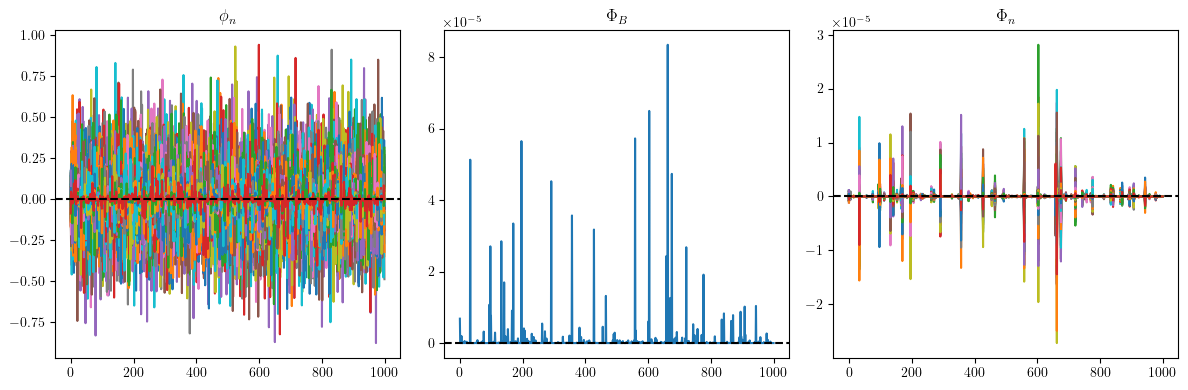

In [45]:
# # Values 
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))
print(ndet)
# First subplot: psi_n
for i in range(ndet):
    y = psi_n[i]
    ax1.plot(y, label=i)
ax1.axhline(0, color='black', linestyle='--')
ax1.set_title(r'$\phi_n$')
# ax1.legend()

# Second subplot: phi_b
ax2.plot(phi_b)
ax2.axhline(0, color='black', linestyle='--')
ax2.set_title(r'$\Phi_B$')

for i in range(ndet):
    y = phi_n.T[i]
    ax3.plot(y, label=i)
ax3.axhline(0, color='black', linestyle='--')
ax3.set_title(r'$\Phi_n$')

# Adjust layout to prevent overlap
plt.tight_layout()

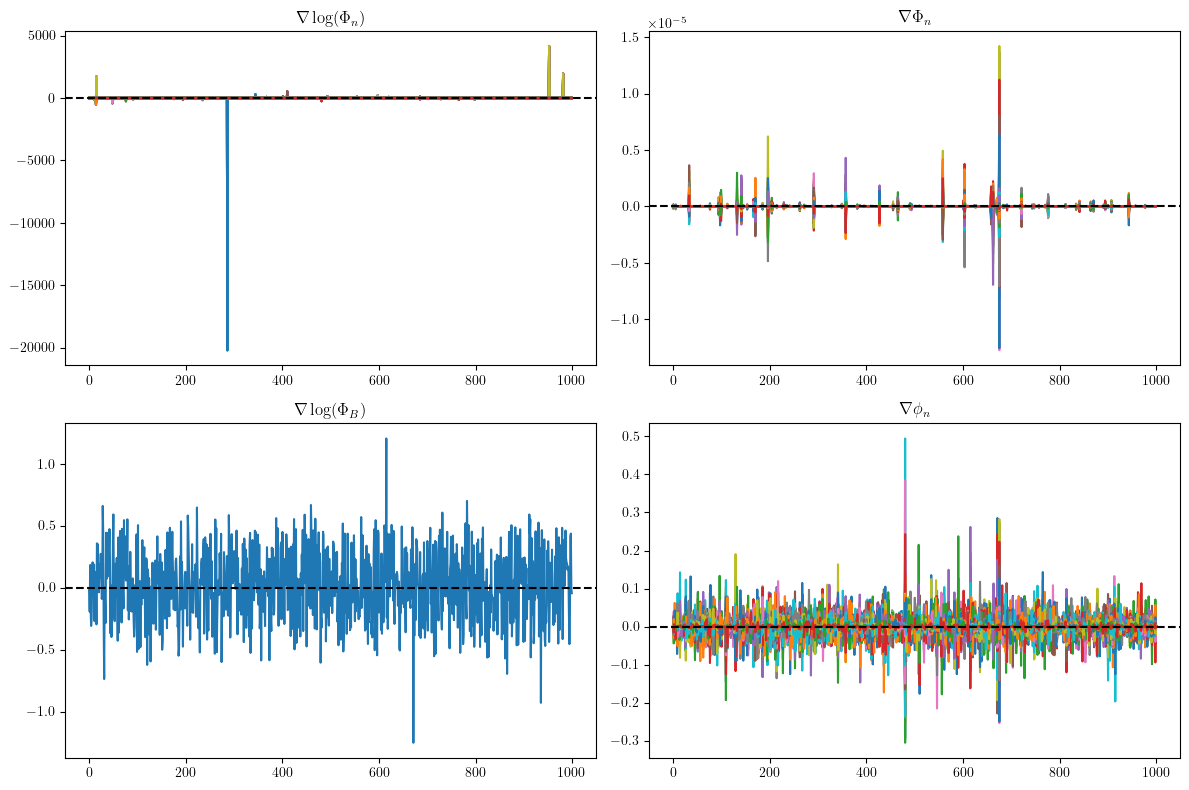

In [46]:
# Create a figure with 2x2 subplots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 8))

# First subplot: loggrad_phi_n
axis = 1
for i in range(ndet):
    y = loggrad_phi_n[i,axis,:]
    ax1.plot(y, label=i)
ax1.axhline(0, color='black', linestyle='--')
ax1.set_title(r'$\nabla \log(\Phi_n)$')

# Second subplot: grad_phi_n
axis = 2
for i in range(ndet):
    y = grad_phi_n[i,axis,:]
    ax2.plot(y, label=i)
    if np.abs(y).max() > 1e6:
        print(i, np.abs(y).max())
ax2.axhline(0, color='black', linestyle='--')
ax2.set_title(r'$\nabla \Phi_n$')

# Third subplot: loggrad_phi_b
y = loggrad_phi_b[axis,:]
ax3.plot(y)
ax3.axhline(0, color='black', linestyle='--')
ax3.set_title(r'$\nabla \log(\Phi_B)$')

# Fourth subplot: grad_psi_n
for i in range(ndet):
    y = grad_psi_n[i,axis,:]
    ax4.plot(y, label=i)
ax4.axhline(0, color='black', linestyle='--')
ax4.set_title(r'$\nabla \phi_n$')

# Adjust layout to prevent overlap
plt.tight_layout()

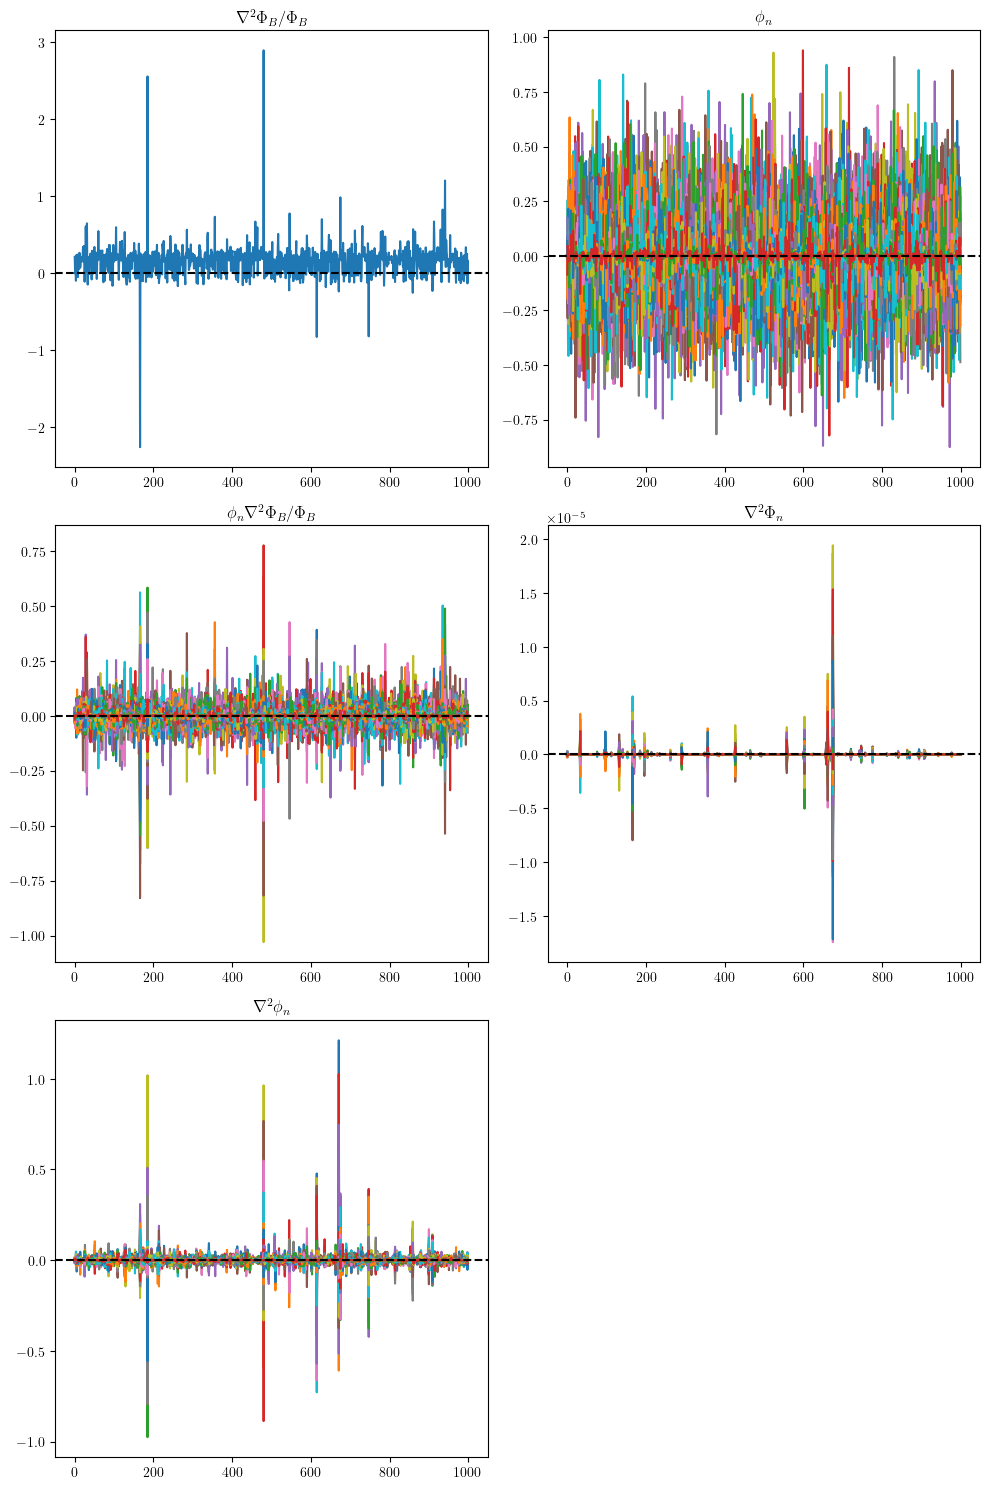

In [47]:
# Create a figure with 2x3 subplots
fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6)) = plt.subplots(3, 2, figsize=(10, 15))

# First subplot: Laplacian of bosonic wavefunction
ax1.plot(lap_phi_b)
ax1.axhline(0, color='black', linestyle='--')
ax1.set_title(r'$\nabla^2 \Phi_B/\Phi_B$')

# Second subplot: Individual wavefunctions
for i in range(ndet):
    y = psi_n[i,:]
    ax2.plot(y, label=i)
ax2.axhline(0, color='black', linestyle='--')
ax2.set_title(r'$\phi_n$')

# Third subplot: Product of bosonic laplacian and wavefunctions
for i in range(ndet):
    y = psi_n[i,:]*lap_phi_b
    ax3.plot(y, label=i)
ax3.axhline(0, color='black', linestyle='--')
ax3.set_title(r'$\phi_n \nabla^2 \Phi_B/\Phi_B$')

# Fourth subplot: Laplacian of individual determinants
for i in range(ndet):
    y = lap_phi_n.T[i,:]
    ax4.plot(y, label=i)
ax4.axhline(0, color='black', linestyle='--')
ax4.set_title(r'$\nabla^2 \Phi_n$')

# Fifth subplot: Laplacian of ratios
for i in range(ndet):
    y = lap_psi_n.T[i,:]
    ax5.plot(y, label=i)
ax5.axhline(0, color='black', linestyle='--')
ax5.set_title(r'$\nabla^2 \phi_n$')

# Hide the last subplot since we only have 5 plots
ax6.set_visible(False)

# Adjust layout to prevent overlap
plt.tight_layout()

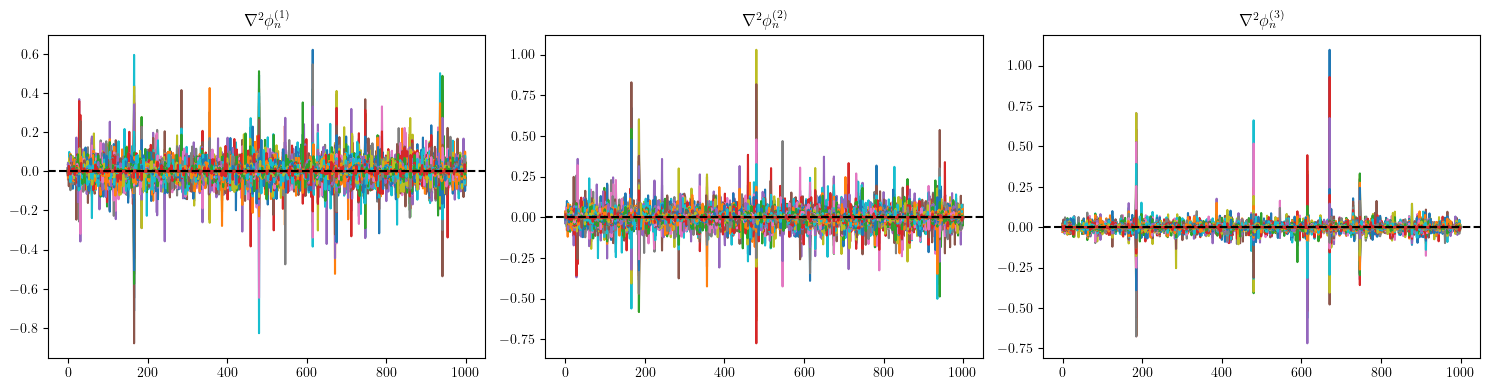

In [48]:
# Contribution to laplacian
# Create a figure with 3 horizontal subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))

for i in range(ndet):
    y = lap_psi_n1.T[i,:]
    ax1.plot(y, label=i)
ax1.axhline(0, color='black', linestyle='--')
ax1.set_title(r'$\nabla^2 \phi_n^{(1)}$')

for i in range(ndet):
    y = lap_psi_n2.T[i,:]
    ax2.plot(y, label=i)
ax2.axhline(0, color='black', linestyle='--')
ax2.set_title(r'$\nabla^2 \phi_n^{(2)}$')

for i in range(ndet):
    y = lap_psi_n3.T[i,:]
    ax3.plot(y, label=i)
ax3.axhline(0, color='black', linestyle='--')
ax3.set_title(r'$\nabla^2 \phi_n^{(3)}$')

# Adjust layout to prevent overlap
plt.tight_layout()

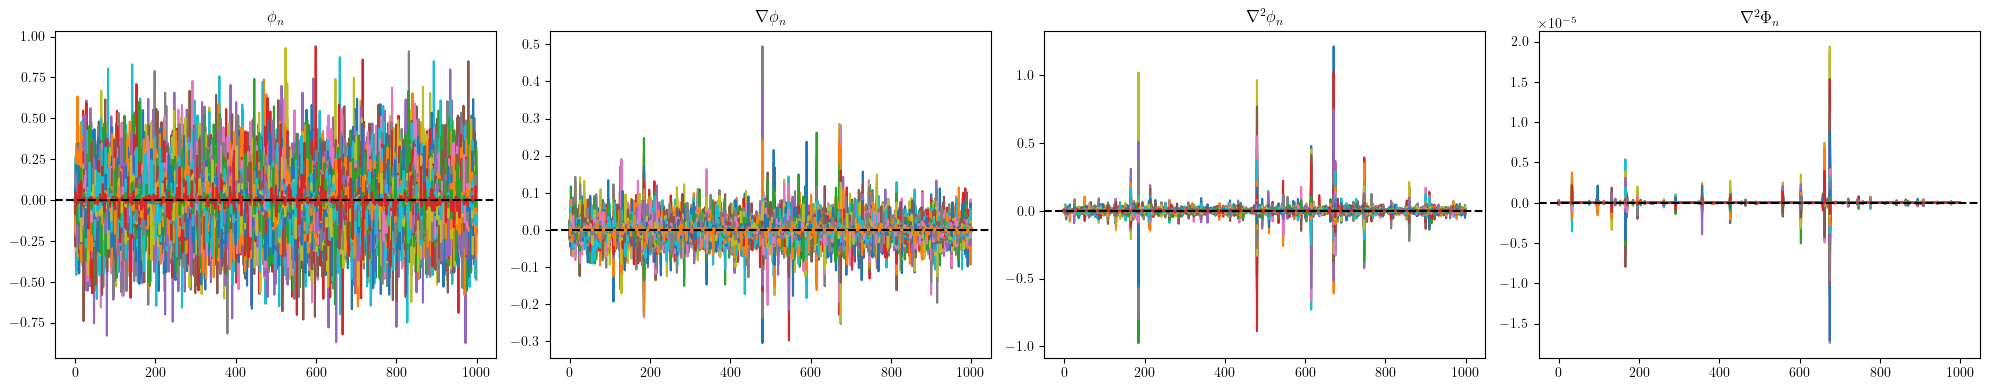

In [49]:
# Create a figure with 3 subplots
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(20, 4))

# First subplot: psi_n
for i in range(ndet):
    x = psi_n[i]
    ax1.plot(x, label=i)
ax1.axhline(0, color='black', linestyle='--')
ax1.set_title(r'$\phi_n$')
# ax1.legend()

# Second subplot: grad_psi_n
for axis in range(3):
    for i in range(ndet):
        y = grad_psi_n[i,axis,:]
        ax2.plot(y, label='{}-{}'.format(axis,i))
ax2.axhline(0, color='black', linestyle='--')
# ax2.legend()
ax2.set_title(r'$\nabla \phi_n$')

# Third subplot: lap_psi_n
for i in range(ndet):
    y = lap_psi_n.T[i,:]
    ax3.plot(y, label=i)
ax3.axhline(0, color='black', linestyle='--')
# ax3.legend()
ax3.set_title(r'$\nabla^2 \phi_n$')


# Fourth subplot: lap_phi_n
for i in range(ndet):
    y = lap_phi_n.T[i,:]
    ax4.plot(y, label=i)
ax4.axhline(0, color='black', linestyle='--')
# ax3.legend()
ax4.set_title(r'$\nabla^2 \Phi_n$')

# Adjust layout to prevent overlap
plt.tight_layout()

In [50]:
lap_n = boson.laplacian_dets(e, epos_s) # ∇²(Phi_n)
# Get value of determinants
phase_n, logval_n = boson.value_dets()   # phase(Phi_n), log(Phi_n)
val_n = phase_n * np.nan_to_num(np.exp(logval_n)) # Phi_n
# Get gradient of determinants
loggrad_n = boson.gradient_dets(e, epos_s) # ∇log(Phi_n) # large

# Get value of bosonic wavefunction
phase_b, logval_b = boson.value() # phase(Phi_B), log(Phi_B)
val_b = phase_b * np.nan_to_num(np.exp(logval_b)) # Phi_B

# Calculate ∇²(Phi_B)/Phi_B
# First term: Sum over determinants l of: (gradient of Phi_l)·(gradient of Phi_l)  [dot product of gradients]

grad_phi_l = np.einsum('nxc, cn->nxc', loggrad_n, val_n)
lap_b1 = np.einsum('nxc, nxc->c', grad_phi_l, grad_phi_l)
lap_b1 += np.einsum('cn, cn->c', val_n, lap_n)
lap_b1 /= val_b**2
# Second term: Minus the square of (sum of Phi_l times gradient of Phi_l)
lap_b2a = np.einsum('cn, nxc->cx', val_n, grad_phi_l)
lap_b2b = np.einsum('cx, cx->c', lap_b2a, lap_b2a)
lap_b2  = lap_b2b / val_b**4
lap_b   = lap_b1 - lap_b2

phases, logvals_phi_n = boson.value_dets() #log(Phi_l)
phi_n = phases * np.nan_to_num(np.exp(logvals_phi_n)) # Phi_l

print(psi_n.shape, grad_phi_l.shape)
lap_b2a2 = np.einsum('nc, nxc->cx', psi_n, grad_phi_l)
lap_b2b2 = np.einsum('cx, cx->c', lap_b2a2, lap_b2a2)
lap_b22  = lap_b2b2 / val_b**2



(324, 1000) (324, 3, 1000)


(1000, 324)
(1000, 324) (324, 3, 1000)


Text(0.5, 1.0, '$(\\nabla \\Phi_n \\cdot \\Phi_n)^2/\\Phi_B^3$')

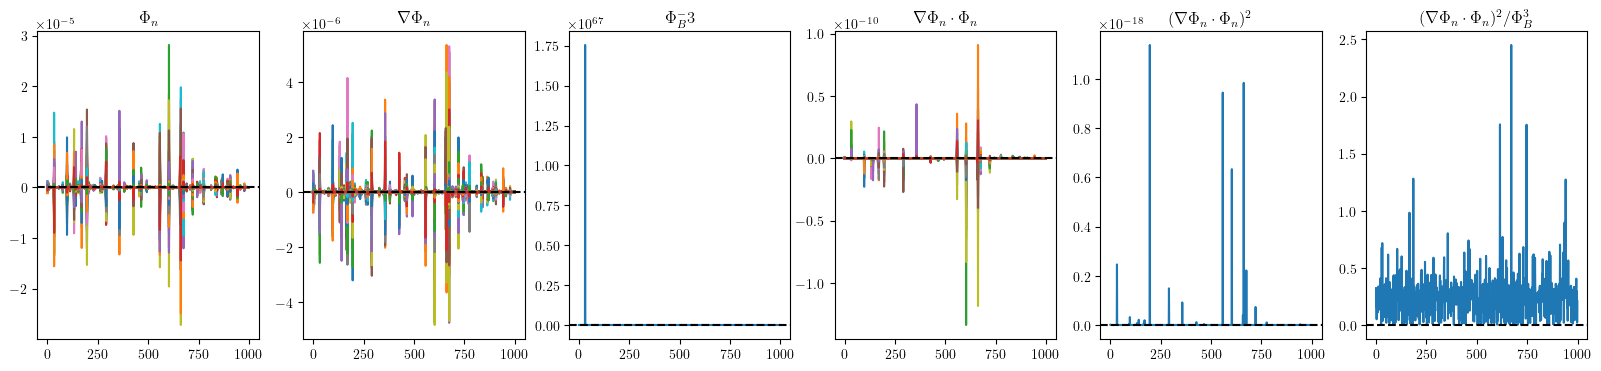

In [51]:
fig, (ax1, ax2, ax3, ax4, ax5, ax6) = plt.subplots(1, 6, figsize=(20, 4))

print(phi_n.shape)
# First subplot: psi_n
for i in range(ndet):
    x = phi_n[:,i]
    ax1.plot(x, label=i)
ax1.axhline(0, color='black', linestyle='--')
ax1.set_title(r'$\Phi_n$')
# ax1.legend()

axis=0
# print(grad_phi_n.shape)
for i in range(ndet):
    x = grad_phi_n[i,axis,:]
    ax2.plot(x, label=i)
ax2.axhline(0, color='black', linestyle='--')
ax2.set_title(r'$\nabla \Phi_n$')
# # ax1.legend()

ax3.plot(1./(phi_b)**3)
ax3.axhline(0, color='black', linestyle='--')
ax3.set_title(r'$\Phi_B^-3$')

print(phi_n.shape, grad_phi_n.shape)
nom_x = np.einsum('cn, nxc->nxc', phi_n, grad_phi_n)
for i in range(ndet):
    ax4.plot(nom_x[i,axis, :], label=i)
ax4.axhline(0, color='black', linestyle='--')
ax4.set_title(r'$\nabla \Phi_n \cdot \Phi_n$')

nnom_x = np.einsum('nxc->xc', nom_x)
nom = np.einsum('xc, xc->c', nnom_x, nnom_x)

ax5.plot(nom)
ax5.axhline(0, color='black', linestyle='--')
ax5.set_title(r'$(\nabla \Phi_n \cdot \Phi_n)^2$')

ax6.plot(nom/val_b**4)
ax6.axhline(0, color='black', linestyle='--')
ax6.set_title(r'$(\nabla \Phi_n \cdot \Phi_n)^2/\Phi_B^3$')


In [52]:

# phases, logvals_phi_n = boson.value_dets() #log(Phi_l)
# phi_n = phases * np.nan_to_num(np.exp(logvals_phi_n)) # Phi_l

# phase_phi_b, logval_phi_b = boson.value() # log(Phi_B)
# phi_b = phase_phi_b * np.nan_to_num(np.exp(logval_phi_b)) # Phi_B

# psi_n = get_psi_basis(boson) # Phi_l/Phi_B



# phases, log_vals = boson.value_dets() #log(Phi_l)
# psis = phases * np.nan_to_num(np.exp(log_vals)) # Phi_l
    
# phase, log_val = boson.value() # log(Phi_B) Eq. 4
# val = phase * np.nan_to_num(np.exp(log_val)) #Phi_B

#     # psi_basis = np.einsum('cn, c->nc', psis, 1./val) # Phi_l/Phi_B, eq. 14
#     # return psi_basis


# deti=6
# fig, (ax1, ax2, ax3, ax4, ax5, ax6) = plt.subplots(1, 6, figsize=(10, 4))
# ax1.plot(phi_n[:,deti])
# ax2.plot(psi_n[deti, :])
# ax3.plot(phi_n[:,deti]/phi_b)
# ax4.plot(phi_b)
# ax5.plot(psis[:, deti]-phi_n[:, deti])
# # ax6.plot(loggrad_phi_n[deti,:,1])




In [53]:
# deti=6
# axis = 0
# print(grad_phi_n.shape)
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
# ax1.plot(grad_phi_n[deti, axis, :])
# ax2.plot(grad_psi_n[deti, axis, :])
